### Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import cv2
import albumentations as A
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import class_weight
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf


from tensorflow.keras import layers, models

import warnings
warnings.filterwarnings('ignore')

2026-01-21 19:48:17.994787: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769024898.179479      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769024898.232485      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769024898.672721      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769024898.672772      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769024898.672775      55 computation_placer.cc:177] computation placer alr

### Load Dataset

In [2]:
landmarks_path= Path("/kaggle/input/final-landmark-dataset/Final Dataset 4 JPG")
classes = os.listdir(landmarks_path)
print(classes)

['The Small Aten Temple', 'Qasr Qarun', 'Pyramid of Meidum', 'Temple of Kom Ombo', 'Temple of Luxor', 'Temple of Isis in Philae', 'Temple of Hathor in Philae', 'Pyramid of Senefru - Bent Pyramid of Senefru', 'Temple of Dakka', 'Temple of Hathor in Dendera', 'Temple of Maharraqa', 'Pyramids of Giza', 'Black Pyramid of Amenemhat III', 'Temple of Horus at Edfu', 'Famine Stele', 'Al Qurn', 'Small Temple of Hathor and Nefertari at Abu Simbel', 'Sphinx', 'Temple of Kalabsha', 'Ptolemaic Temple of Hathor in Deir el Medina', 'Kiosk of Trajan in Philae', 'Temple of Khonsu in Karnak', 'Temple of Karnak', 'Colossoi of Memnon', 'Pyramid of Seila', 'Temple of Hatshepsut in Deir El Bahari', 'Temple of Habu', 'Osireion', 'Ramessum', 'Pyramid of Saqqara - Pyramid of Djoser', 'Temple of Amada', 'Tomb of Horemheb in Saqqara', 'Pyramid of Sahure', 'Sphinx of Memphis', 'Temple of Seti I in Abydos', 'The Roman Mammisi in Dendera', 'Temple of Wadi es-Sebua - Temple of Ramesses II', 'Tomb of Petosiris', 'Tem

In [3]:
len(classes)

52

### Helper Functions

In [4]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def list_subdirs(path: Path):
    return sorted([p for p in path.iterdir() if p.is_dir()])

def count_images_recursive(path: Path):
    return sum(1 for p in path.rglob("*") if p.suffix.lower() in IMG_EXTS)

def count_images_in_dir(path: Path):
    return sum(1 for p in path.iterdir() if p.suffix.lower() in IMG_EXTS)

In [5]:
def make_df(landmarks_path: Path):
    rows = []

    for class_dir in list_subdirs(landmarks_path):
        landmark_name = os.path.basename(class_dir)
        for p in class_dir.iterdir():
            if p.suffix.lower() in IMG_EXTS:
                rows.append({"label": str(landmark_name)  , "path": str(p)})

    df = pd.DataFrame(rows, columns=["label", "path"])
    return df

df=make_df(landmarks_path)
df.sample(10)

,label,path
375,Colossoi of Memnon,/kaggle/input/final-landmark-dataset/Final Dat...
2532,Pyramids of Giza,/kaggle/input/final-landmark-dataset/Final Dat...
555,Famine Stele,/kaggle/input/final-landmark-dataset/Final Dat...
248,Colossoi of Memnon,/kaggle/input/final-landmark-dataset/Final Dat...
2615,Pyramids of Giza,/kaggle/input/final-landmark-dataset/Final Dat...
5933,Tomb of Horemheb in Saqqara,/kaggle/input/final-landmark-dataset/Final Dat...
4660,Temple of Isis in Philae,/kaggle/input/final-landmark-dataset/Final Dat...
1749,Pyramid of Senefru - Bent Pyramid of Senefru,/kaggle/input/final-landmark-dataset/Final Dat...
1873,Pyramid of Senefru - Bent Pyramid of Senefru,/kaggle/input/final-landmark-dataset/Final Dat...
322,Colossoi of Memnon,/kaggle/input/final-landmark-dataset/Final Dat...


In [6]:
print("Dataframe shape:", df.shape)

Dataframe shape: (6000, 2)


### EDA

label
Pyramids of Giza                                      814
Temple of Hatshepsut in Deir El Bahari                455
Pyramid of Senefru - Bent Pyramid of Senefru          439
Colossoi of Memnon                                    436
The Great Temple of Ramesses II at Abu Simbel         363
Sphinx                                                337
Pyramid of Saqqara - Pyramid of Djoser                252
Ramessum                                              219
Temple of Horus at Edfu                               192
Kiosk of Trajan in Philae                             171
Temple of Kom Ombo                                    161
Temple of Luxor                                       146
Temple of Isis in Philae                              144
Temple of Hathor in Dendera                           114
Pompeys Pillar - Serapeum of Alexandria               111
Small Temple of Hathor and Nefertari at Abu Simbel     99
Temple of Karnak                                       94
Black Py

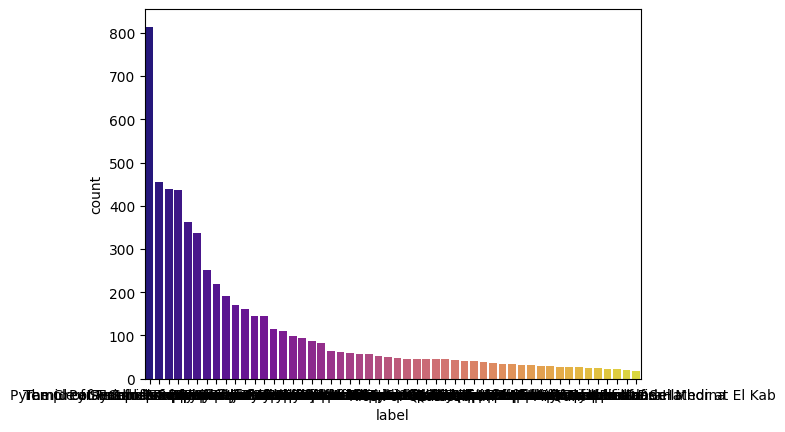

In [7]:
sns.countplot(data=df,x='label',palette='plasma',order=df['label'].value_counts().index )
df['label'].value_counts()

### Data Preprocessing

In [8]:
def show(title, img):
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

def load_bgr(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise ValueError(f"Could not read {path}")
    return img_bgr

def bgr_to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

In [9]:
image_size = 128
def resize(image, size=image_size):
  return cv2.resize(image,(size,size), interpolation=cv2.INTER_AREA)

#### On-the-fly Augmentation

In [ ]:
train_aug = A.Compose([
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.2),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, border_mode=cv2.BORDER_REPLICATE, p=0.5), 
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=15, border_mode=cv2.BORDER_REPLICATE, p=0.6)
])

def apply_augmentation(image):
    return train_aug(image=image)["image"]

In [11]:
def normalize(image):
  return image/255.0

In [12]:
sample_row = df.iloc[3903]
sample_path = sample_row["path"]
sample_label = sample_row["label"]

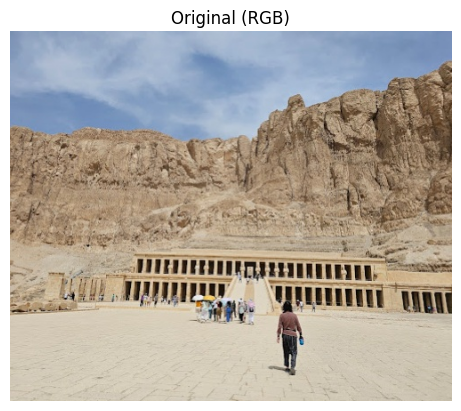

Original shape: (416, 497, 3) dtype: uint8


In [13]:
image_BGR = load_bgr(sample_path)
image_RGB = bgr_to_rgb(image_BGR)

show("Original (RGB)", image_RGB)
print("Original shape:", image_RGB.shape, "dtype:", image_RGB.dtype)

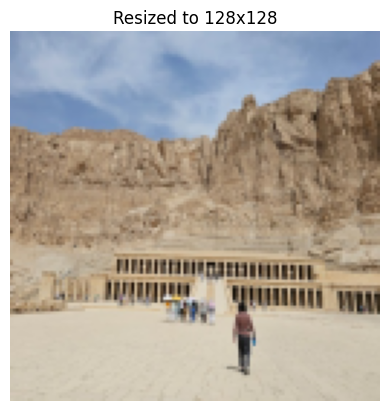

Resized shape: (128, 128, 3)


In [14]:
image_resized= resize(image_RGB,image_size)
show(f"Resized to {image_size}x{image_size}", image_resized)
print("Resized shape:", image_resized.shape)

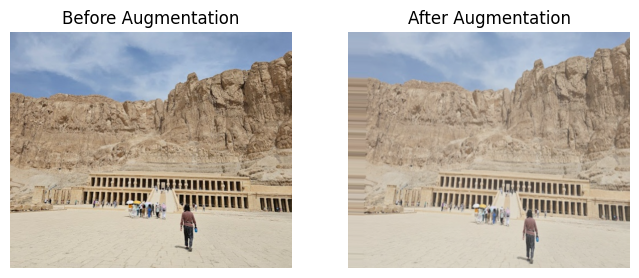

In [19]:
image_augmented = apply_augmentation(image_RGB)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(image_RGB); plt.title("Before Augmentation"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(image_augmented); plt.title("After Augmentation");  plt.axis("off")
plt.show()

In [20]:
def preprocess_image(path, size=image_size, augment=False):
    image_BGR = load_bgr(path)
    image_RGB = bgr_to_rgb(image_BGR)
    image_resized = resize(image_RGB, size)

    if augment:
        image_processed = apply_augmentation(image_resized)
    else:
        image_processed = image_resized

    image_normalized = normalize(image_processed)
    image_normalized = image_normalized.astype(np.float32)
    return image_normalized

In [21]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

class TFDataset:
    def __init__(self, df, augment=False, batch_size=BATCH_SIZE, shuffle=True, image_size=image_size):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.image_size = image_size if isinstance(image_size, int) else image_size[0]
        self.dataset = self._build_dataset()

    def _load_and_preprocess(self, path, label):
        def _py_preprocess(path_str):
            path_str = path_str.decode("utf-8")
            img = preprocess_image(
                path_str,
                size=self.image_size,
                augment=self.augment
            )
           
            return img.astype("float32")

        img = tf.numpy_function(_py_preprocess, [path], tf.float32)
        img.set_shape((self.image_size, self.image_size, 3))
        return img, label

    def _build_dataset(self):
        paths = self.df["path"].values
        labels = self.df["label"].values.astype("float32")

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

        if self.shuffle:
            ds = ds.shuffle(buffer_size=len(self.df), reshuffle_each_iteration=True)

        ds = ds.map(self._load_and_preprocess, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(self.batch_size)
        ds = ds.prefetch(AUTOTUNE)
        return ds

    def __iter__(self):
        return iter(self.dataset)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

### Model Pipeline

#### Data split

In [23]:
df.shape[0]

6000

In [24]:

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.3,
    stratify=temp_df["label"],
    random_state=42
)

In [25]:
train_df['label'].value_counts()

label
Pyramids of Giza                                      651
Temple of Hatshepsut in Deir El Bahari                364
Pyramid of Senefru - Bent Pyramid of Senefru          351
Colossoi of Memnon                                    349
The Great Temple of Ramesses II at Abu Simbel         290
Sphinx                                                269
Pyramid of Saqqara - Pyramid of Djoser                202
Ramessum                                              175
Temple of Horus at Edfu                               154
Kiosk of Trajan in Philae                             137
Temple of Kom Ombo                                    129
Temple of Luxor                                       117
Temple of Isis in Philae                              115
Temple of Hathor in Dendera                            91
Pompeys Pillar - Serapeum of Alexandria                89
Small Temple of Hathor and Nefertari at Abu Simbel     79
Temple of Karnak                                       75
Black Py

In [27]:
print("Train size:", train_df.shape[0])
print("Test size:", test_df['label'].shape[0])
print("Valid size:", valid_df['label'].shape[0])

Train size: 4800
Test size: 360
Valid size: 840


#### Offline Augmentation

In [28]:
augmented_data = []
base_dir = Path("/kaggle/input/landmarks-augmented-dataset/augmented_train")


for class_name in os.listdir(base_dir):
    class_dir = os.path.join(base_dir, class_name)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        path = os.path.join(class_dir, fname)
        augmented_data.append({"path": path, "label": class_name.replace("_", " ")})

aug_df = pd.DataFrame(augmented_data)
aug_df.shape

(17731, 2)

In [29]:
aug_df.sample(5)

,path,label
9418,/kaggle/input/landmarks-augmented-dataset/augm...,The Great Temple of Ramesses II at Abu Simbel
14593,/kaggle/input/landmarks-augmented-dataset/augm...,Pyramid of Meidum
2656,/kaggle/input/landmarks-augmented-dataset/augm...,Temple of Luxor
14691,/kaggle/input/landmarks-augmented-dataset/augm...,Pyramid of Sahure
5902,/kaggle/input/landmarks-augmented-dataset/augm...,Pyramid of Hawara - White pyramid of Amnemhat III


#### Label Encoding

In [ ]:
encoder = LabelEncoder()
aug_df['label'] = encoder.fit_transform(aug_df['label'])

test_df['label'] = encoder.transform(test_df['label'])
valid_df['label'] = encoder.transform(valid_df['label'])

In [31]:
counts = aug_df['label'].value_counts()
counts.index = encoder.inverse_transform(counts.index.astype(int))

counts

Pyramids of Giza                                      651
The Great Temple of Ramesses II at Abu Simbel         580
Kiosk of Trajan in Philae                             548
Sphinx                                                538
Temple of Kom Ombo                                    516
Temple of Dakka                                       490
Pyramid of Userkaf                                    470
Temple of Luxor                                       468
Pyramid of Hawara - White pyramid of Amnemhat III     460
Temple of Merit Amun                                  460
Temple of Isis in Philae                              460
The Roman Mammisi in Dendera                          420
Temple of Seti I in Abydos                            410
Pyramid of Saqqara - Pyramid of Djoser                404
Famine Stele                                          390
Temple of Kalabsha                                    370
Kiosk of Qertassi                                     370
Temple of Hats

#### Class weights

In [32]:
aug_df['label'].values

array([39, 39, 39, ..., 41, 41, 41])

In [ ]:
y = aug_df['label']  

classes = np.unique(y)
class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y
)

class_weights = dict(zip(classes, class_weights_array))
print(class_weights)

{np.int64(0): np.float64(1.5499125874125874), np.int64(1): np.float64(1.2177884615384615), np.int64(2): np.float64(0.9770222614062155), np.int64(3): np.float64(0.8743096646942801), np.int64(4): np.float64(0.9215696465696466), np.int64(5): np.float64(0.622227681078046), np.int64(6): np.float64(1.7049038461538462), np.int64(7): np.float64(0.9578111495246326), np.int64(8): np.float64(1.5499125874125874), np.int64(9): np.float64(0.74126254180602), np.int64(10): np.float64(1.2915938228438228), np.int64(11): np.float64(1.671474358974359), np.int64(12): np.float64(0.8440118050266565), np.int64(13): np.float64(2.0057692307692307), np.int64(14): np.float64(0.9714551829936445), np.int64(15): np.float64(1.7049038461538462), np.int64(16): np.float64(0.7254909983633387), np.int64(17): np.float64(0.5237799834574028), np.int64(18): np.float64(1.0028846153846154), np.int64(19): np.float64(0.9742307692307692), np.int64(20): np.float64(1.0790530671859786), np.int64(21): np.float64(1.363923076923077), np

In [34]:
train_data = TFDataset(
    aug_df,
    augment=True,
    batch_size=BATCH_SIZE,
    shuffle=True,
    image_size=image_size)

val_data = TFDataset(
    valid_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=False,
    image_size=image_size
)

I0000 00:00:1769025192.911811      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [35]:
print("Number of samples:", len(train_data.df))
print("Number of batches:", len(train_data))

Number of samples: 17731
Number of batches: 555


### LeNet Model Training

In [36]:
IMG_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 52

In [ ]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(6, kernel_size=5, activation='relu', padding='same')(inputs)
x = layers.AveragePooling2D(pool_size=(2, 2), strides=2)(x)

x = layers.Conv2D(16, kernel_size=5, activation='relu')(x)
x = layers.AveragePooling2D(pool_size=(2, 2), strides=2)(x)

x = layers.Conv2D(120, kernel_size=5, activation='relu')(x)

x = layers.Flatten()(x)
x = layers.Dense(84, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 64, 64, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 60, 60, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 30, 30, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 120)    │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 81120)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │     6,814,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 52)             │         4,420 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,869,576 (26.21 MB)

 Trainable params: 6,869,576 (26.21 MB)

 Non-trainable params: 0 (0.00 B)

#### Training

In [ ]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [47]:
history = model.fit(
    train_data.dataset,
    validation_data=val_data.dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 53s 88ms/step - accuracy: 0.4720 - loss: 1.9253 - val_accuracy: 0.5393 - val_loss: 1.6707 - learning_rate: 0.0010
Epoch 2/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 46s 84ms/step - accuracy: 0.5885 - loss: 1.4233 - val_accuracy: 0.6786 - val_loss: 1.0654 - learning_rate: 0.0010
Epoch 3/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 47s 85ms/step - accuracy: 0.6680 - loss: 1.0997 - val_accuracy: 0.7333 - val_loss: 0.9085 - learning_rate: 0.0010
Epoch 4/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 46s 83ms/step - accuracy: 0.7061 - loss: 0.9599 - val_accuracy: 0.7571 - val_loss: 0.8610 - learning_rate: 0.0010
Epoch 5/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 46s 84ms/step - accuracy: 0.7534 - loss: 0.8098 - val_accuracy: 0.8107 - val_loss: 0.6899 - learning_rate: 0.0010
Epoch 6/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 47s 85ms/step - accuracy: 0.7839 - loss: 0.6912 - val_accuracy: 0.8262 - val_loss: 0.6152 - learning_rate: 0.0010
Epoch 7/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 47s 84ms/step - accuracy: 0.8035 - l

#### Evaluation Results

In [48]:
losses=pd.DataFrame(history.history)

Text(0.5, 1.0, 'Model Accuracy during Training')

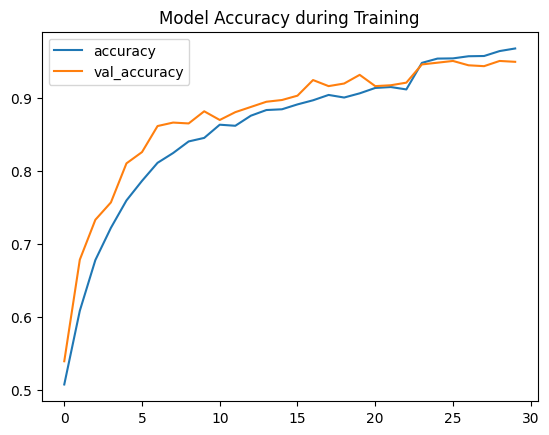

In [49]:
losses[['accuracy','val_accuracy']].plot()
plt.title('Model Accuracy during Training')

Text(0.5, 1.0, 'Model Loss during Training')

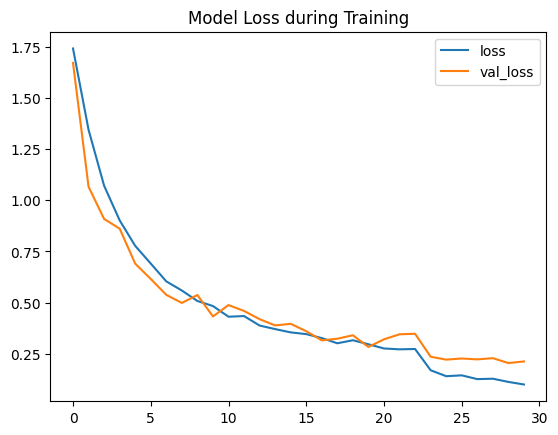

In [50]:
losses[['loss','val_loss']].plot()
plt.title('Model Loss during Training')

In [51]:
val_loss, val_accuracy=model.evaluate(val_data.dataset)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9539 - loss: 0.1961
Validation Loss: 0.2043
Validation Accuracy: 0.9512


In [52]:
test_data = TFDataset(
    test_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=False,
    image_size=image_size,
)

In [53]:
print("Number of samples:", len(test_data.df))
print("Number of batches:", len(test_data))

Number of samples: 360
Number of batches: 12


#### Classification Report

In [54]:
y_true = np.concatenate([y for x, y in val_data.dataset], axis=0)
y_pred = np.argmax(model.predict(val_data.dataset), axis=1)

print(classification_report(y_true, y_pred))

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step
              precision    recall  f1-score   support

         0.0       1.00      0.75      0.86         4
         1.0       0.93      1.00      0.96        13
         2.0       0.95      0.97      0.96        61
         3.0       1.00      1.00      1.00         7
         4.0       1.00      1.00      1.00         6
         5.0       0.96      1.00      0.98        24
         6.0       1.00      1.00      1.00         4
         7.0       0.94      1.00      0.97        15
         8.0       1.00      1.00      1.00         4
         9.0       1.00      0.88      0.93         8
        10.0       1.00      1.00      1.00        11
        11.0       1.00      0.89      0.94         9
        12.0       0.89      0.94      0.92        35
        13.0       0.75      1.00      0.86         3
        14.0       0.94      0.97      0.95        62
        15.0       0.67      0.50      0.57         4
        16.0       1.00      0.75      0.

In [55]:
y_true = np.concatenate([y for x, y in test_data.dataset], axis=0)
y_pred = np.argmax(model.predict(test_data.dataset), axis=1)

print(classification_report(y_true, y_pred))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         2
         1.0       1.00      1.00      1.00         5
         2.0       1.00      1.00      1.00        26
         3.0       1.00      1.00      1.00         3
         4.0       1.00      0.67      0.80         3
         5.0       1.00      1.00      1.00        10
         6.0       1.00      1.00      1.00         1
         7.0       1.00      1.00      1.00         7
         8.0       1.00      1.00      1.00         1
         9.0       1.00      0.75      0.86         4
        10.0       1.00      1.00      1.00         5
        11.0       1.00      1.00      1.00         4
        12.0       0.93      0.93      0.93        15
        13.0       1.00      1.00      1.00         1
        14.0       0.96      1.00      0.98        26
        15.0       1.00      1.00      1.00         1
        16.0       1.00      0.75      0.

In [56]:
report = classification_report(y_true, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
0.0,1.000000,1.000000,1.000000,2.000000
1.0,1.000000,1.000000,1.000000,5.000000
2.0,1.000000,1.000000,1.000000,26.000000
3.0,1.000000,1.000000,1.000000,3.000000
4.0,1.000000,0.666667,0.800000,3.000000
5.0,1.000000,1.000000,1.000000,10.000000
6.0,1.000000,1.000000,1.000000,1.000000
7.0,1.000000,1.000000,1.000000,7.000000
8.0,1.000000,1.000000,1.000000,1.000000
9.0,1.000000,0.750000,0.857143,4.000000


In [57]:
print("Overall precision:", report["weighted avg"]["precision"])
print("Overall recall:", report["weighted avg"]["recall"])
print("Overall f1-score:", report["weighted avg"]["f1-score"])
print("Overall accuracy:",report["accuracy"])

Overall precision: 0.9690102880658436
Overall recall: 0.9638888888888889
Overall f1-score: 0.9642592190258525
Overall accuracy: 0.9638888888888889


### Test Inference

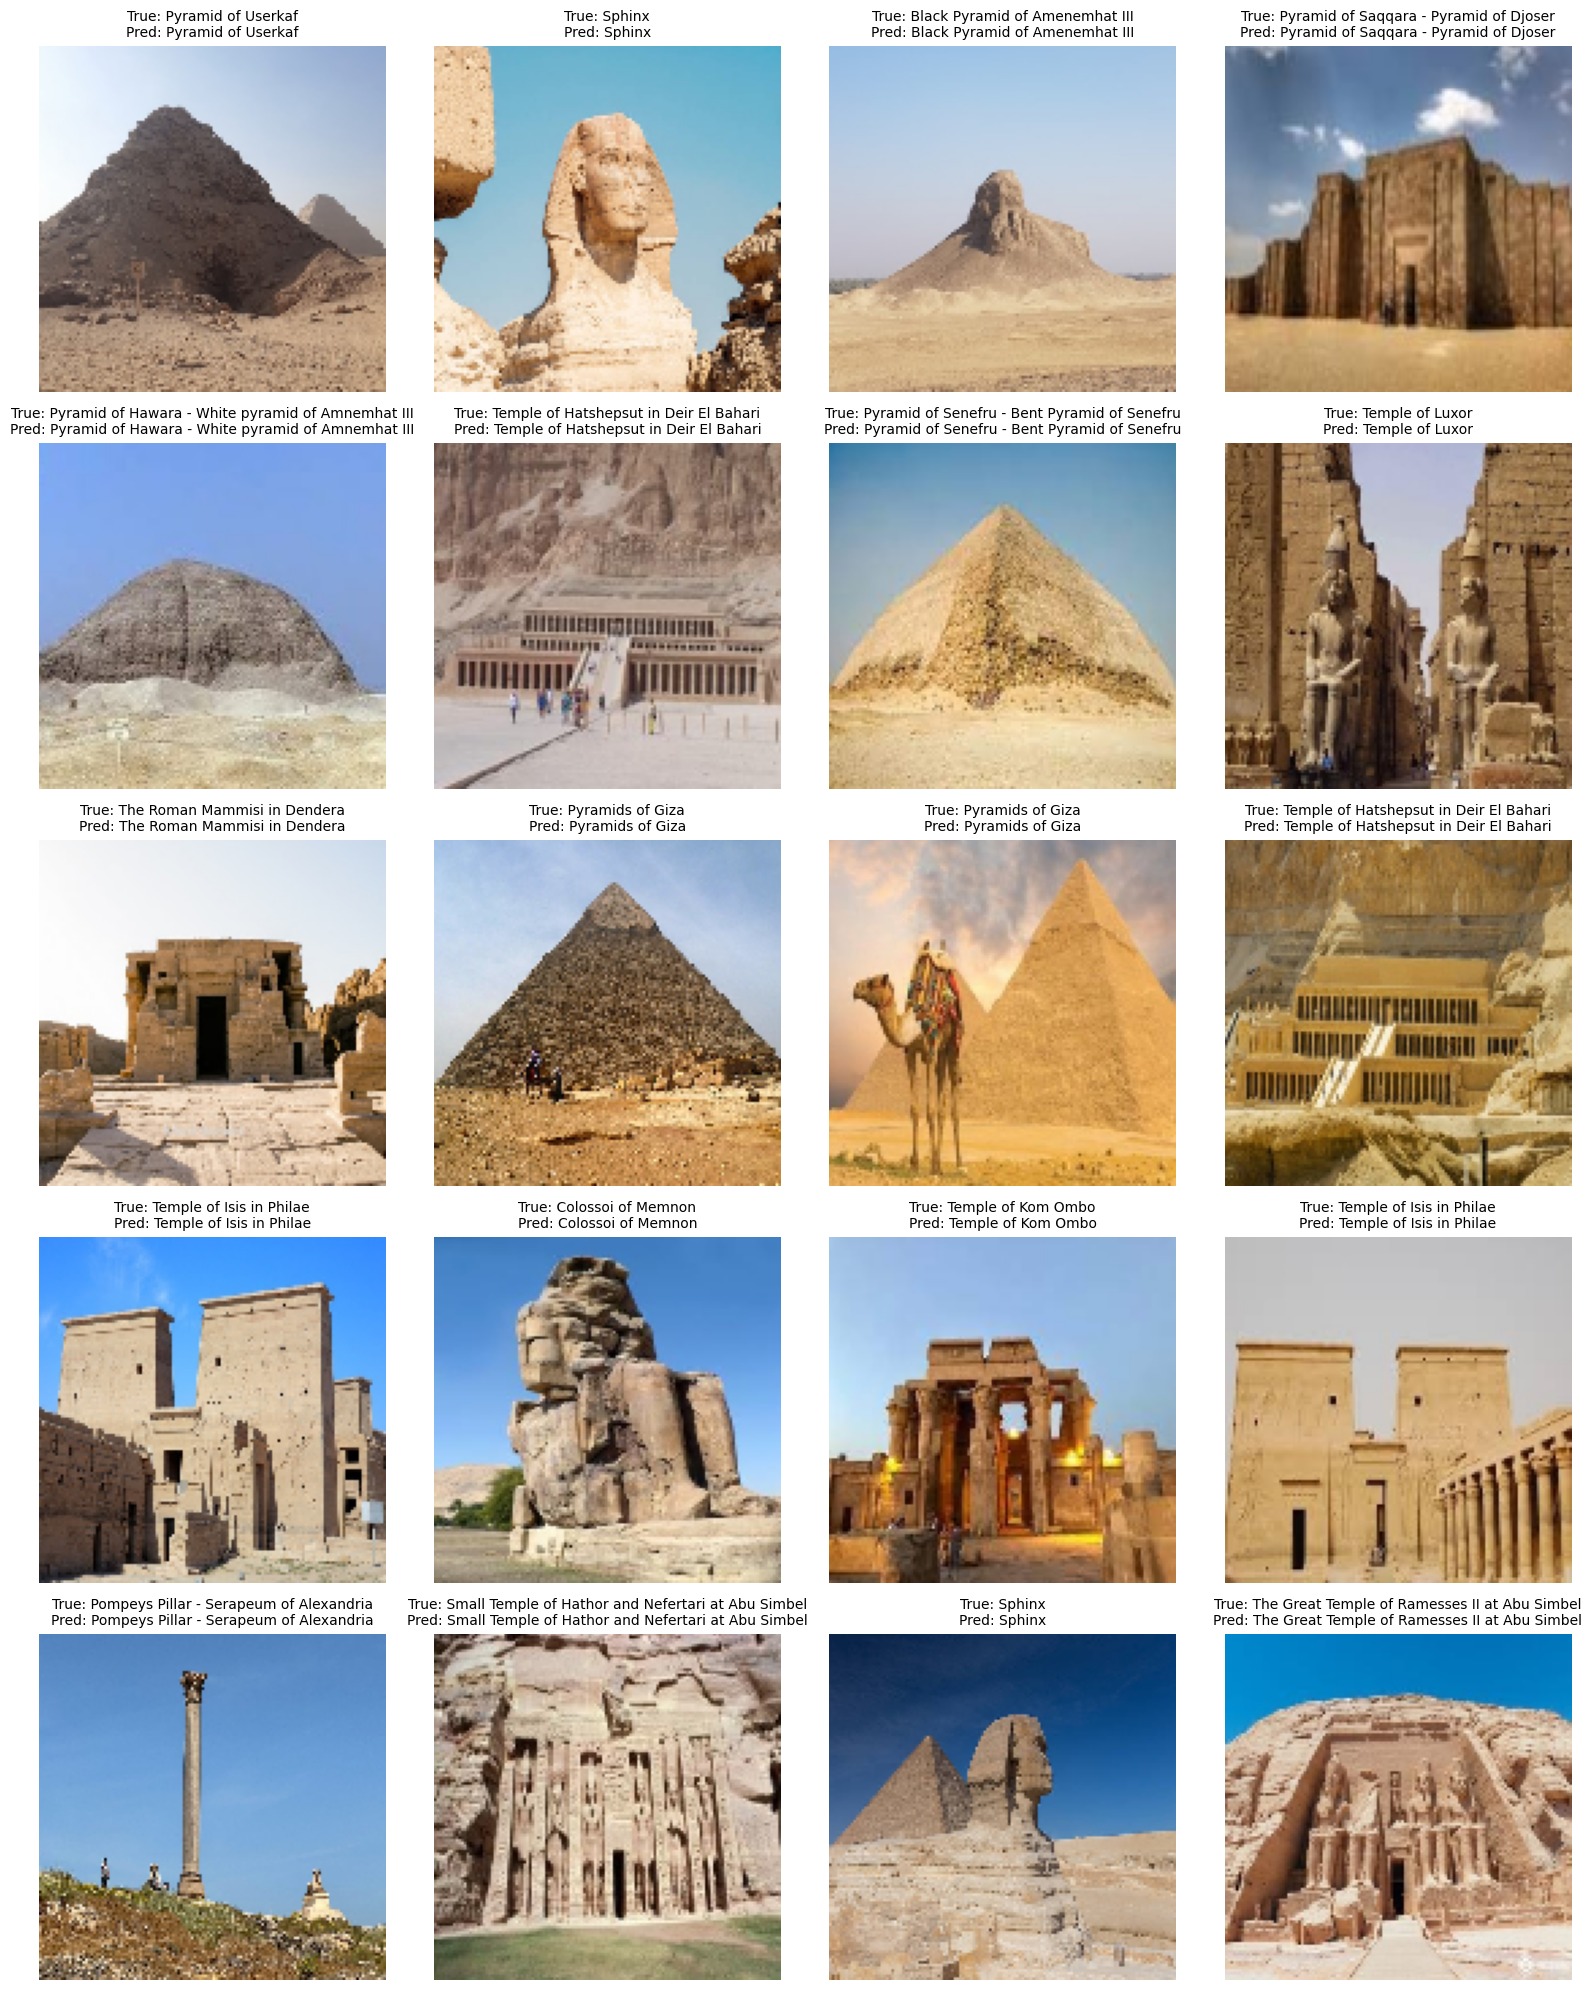

In [ ]:
def display_original_samples(df, model, encoder, image_size=image_size, n=12):
    samples = df.sample(n)

    cols = 4
    rows = math.ceil(n / cols)

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (_, row) in enumerate(samples.iterrows()):
        path = row["path"]
        true_id = int(row["label"])

        img_bgr = cv2.imread(path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (image_size, image_size))

        x = img_resized.astype(np.float32)
        x = x.astype(np.float32) / 255.0
        x = np.expand_dims(x, axis=0)

        pred = model.predict(x, verbose=0)
        pred_id = np.argmax(pred)

        true_label = encoder.inverse_transform([true_id])[0]
        pred_label = encoder.inverse_transform([pred_id])[0]
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_resized)
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

display_original_samples(test_df, model, encoder, image_size=image_size, n=20)



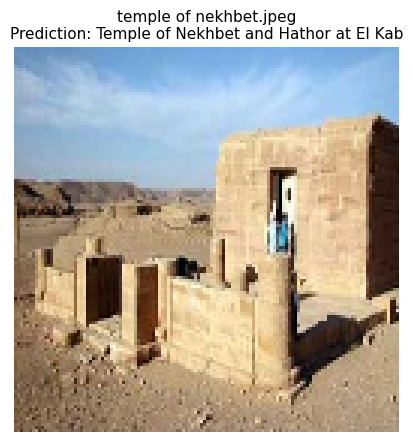

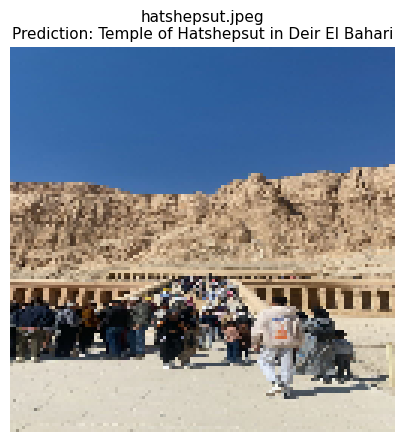

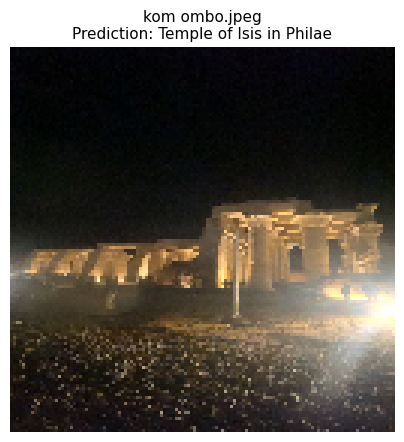

In [61]:
TEST_FOLDER ="/kaggle/input/test-sample"
IMAGE_SIZE = 128
MAX_IMAGES = 12

image_files = [f for f in os.listdir(TEST_FOLDER) if f.lower().endswith((".jpg", ".jpeg", ".png"))][:MAX_IMAGES]

for img_file in image_files:
    img_path = os.path.join(TEST_FOLDER, img_file)

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"Could not read {img_path}")
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMAGE_SIZE, IMAGE_SIZE))

    x = img_resized.astype(np.float32) / 255.0
    x = np.expand_dims(x, axis=0)

    pred = model.predict(x, verbose=0)
    pred_id = np.argmax(pred, axis=1)[0]
    pred_label = encoder.inverse_transform([pred_id])[0]

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.title(f"{img_file}\nPrediction: {pred_label}", fontsize=11)
    plt.axis("off")
    plt.show()

### Save Outputs

In [64]:
import pickle
model.save('/kaggle/working/lenet.keras')

encoder_file = "label_encoder.pkl"

with open(encoder_file, "wb") as f:
    pickle.dump(encoder, f)